In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as constant

In [2]:
def jo(n, m, KT):
    K = 1 / np.sqrt(2 * np.pi)
    e = constant.e
    return K * e * n * np.sqrt(KT / m)

In [3]:
def Jnet(Vs):
    e = 1.6e-19
    me = 9.109e-31
    mi = 1.673e-27
    KTe = 7.5e3 * e
    KTi = 10e3 * e
    n = 1.25e6
    
    A1 = jo(n, me, KTe) * np.exp(-e * np.abs(Vs) / KTe)
    A2 = jo(n, mi, KTi) * (1 + e * np.abs(Vs) / KTi)
    
    return A1 - A2

In [4]:
def dv_dt(Vs, t, C_body, Area):
    j_net = Jnet(Vs)
    return -j_net * Area / C_body

In [5]:
def runge_kutta_4(f, V0, t, C_body, Area):
    Vs = np.zeros(len(t))
    Vs[0] = V0
    dt = t[1] - t[0]
    
    for i in range(1, len(t)):
        k1 = dt * f(Vs[i-1], t[i-1], C_body, Area)
        k2 = dt * f(Vs[i-1] + 0.5 * k1, t[i-1] + 0.5 * dt, C_body, Area)
        k3 = dt * f(Vs[i-1] + 0.5 * k2, t[i-1] + 0.5 * dt, C_body, Area)
        k4 = dt * f(Vs[i-1] + k3, t[i-1] + dt, C_body, Area)
        Vs[i] = Vs[i-1] + (k1 + 2 * k2 + 2 * k3 + k4) / 6
    
    return Vs

In [6]:
def find_saturation_time(t, Vs_solution):
    slope_threshold = 1e-5
    for i in range(1, len(Vs_solution)):
        slope = abs((Vs_solution[i] - Vs_solution[i-1]) / (t[i] - t[i-1]))
        if slope < slope_threshold:
            return t[i]
    return t[-1]

Solar Panel - Saturation Time: 21.4376 s, Final Potential: -19095.1529 V
Cuboid With Dielectric - Saturation Time: 7.6828 s, Final Potential: -19095.1529 V


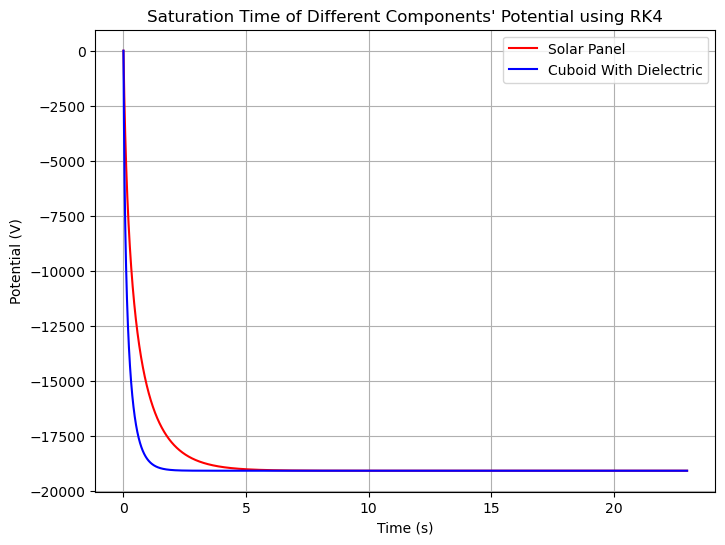

In [13]:
t0 = 0.0
t_end = 23.0
num_points = 100000
t = np.linspace(t0, t_end, num_points)
Vs_initial = 0.0

# Plot and Calculate Saturation Time
plt.figure(figsize=(8, 6))
for C_body, Area, label, co in [
    (4.0e-11, 1, "Solar Panel", 'Red'),
    (8.5e-11, 6.2424, "Cuboid With Dielectric", 'Blue')
]:
    Vs_solution = runge_kutta_4(dv_dt, Vs_initial, t, C_body, Area)
    plt.plot(t, Vs_solution, label=label, color=co)
    
    # Calculate saturation time using slope method
    time_slope = find_saturation_time(t, Vs_solution)
    
    # Find the final potential (last value)
    final_potential = Vs_solution[-1]
    
    print(f"{label} - Saturation Time: {time_slope:.4f} s, Final Potential: {final_potential:.4f} V")

# Customize x-axis ticks with a step of 0.5
plt.xlabel("Time (s)")
plt.ylabel("Potential (V)")
plt.legend()
plt.title("Saturation Time of Different Components' Potential using RK4")
plt.grid(True)
plt.show()

Solar Panel - Saturation Time: 21.4376 s, Final Potential: -19095.1529 V
Cuboid Without Dielectric - Saturation Time: 6.6298 s, Final Potential: -19095.1529 V


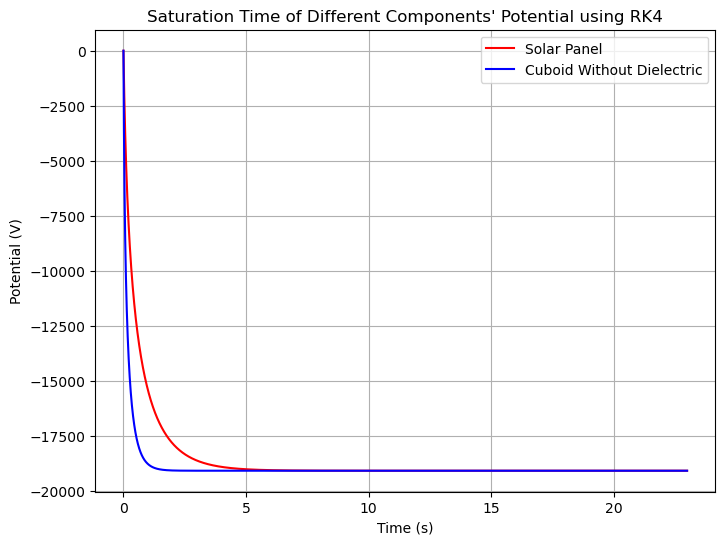

In [14]:
t0 = 0.0
t_end = 23.0
num_points = 100000
t = np.linspace(t0, t_end, num_points)
Vs_initial = 0.0

# Plot and Calculate Saturation Time
plt.figure(figsize=(8, 6))
for C_body, Area, label, co in [
    (4.0e-11, 1, "Solar Panel", 'Red'),
    (7.0e-11, 6, "Cuboid Without Dielectric", 'Blue')
]:
    Vs_solution = runge_kutta_4(dv_dt, Vs_initial, t, C_body, Area)
    plt.plot(t, Vs_solution, label=label, color=co)
    
    # Calculate saturation time using slope method
    time_slope = find_saturation_time(t, Vs_solution)
    
    # Find the final potential (last value)
    final_potential = Vs_solution[-1]
    
    print(f"{label} - Saturation Time: {time_slope:.4f} s, Final Potential: {final_potential:.4f} V")

# Customize x-axis ticks with a step of 0.5
plt.xlabel("Time (s)")
plt.ylabel("Potential (V)")
plt.legend()
plt.title("Saturation Time of Different Components' Potential using RK4")
plt.grid(True)
plt.show()